In [4]:
import pandas as pd
import numpy as np
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')

In [5]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_887/4292836912.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['medv'],hist=True)


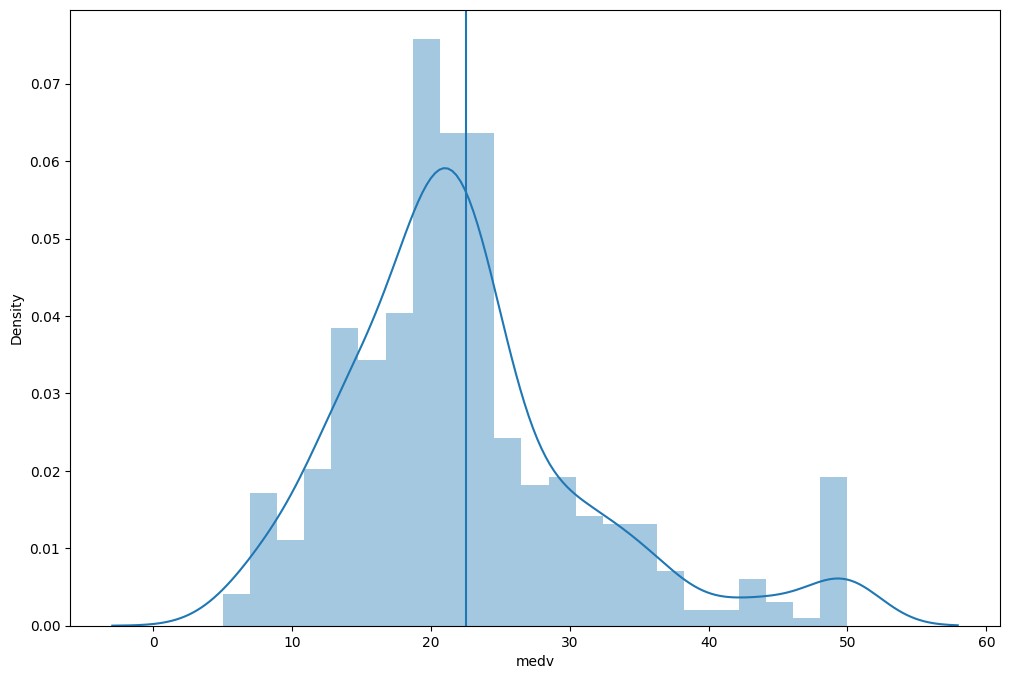

In [9]:
import pandas as pd
df=pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')
plt.figure(figsize=(12,8))
sns.distplot(df['medv'],hist=True)
plt.axvline(df['medv'].mean())
plt.show()

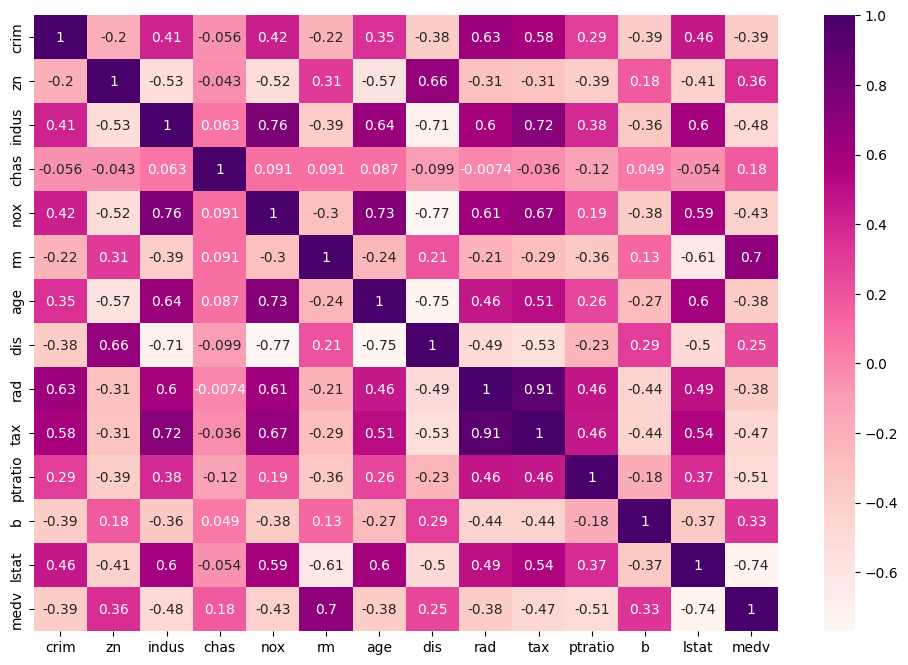

In [10]:
#corelation
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(method='pearson'), annot=True, cmap='RdPu')
plt.show()

In [11]:
X=df.drop(['rad','medv'], axis=1)
Y=df['medv']

In [13]:
#splitting
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
X_scaled=scaler.fit_transform(X)

In [14]:
#test run
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X_scaled,Y,test_size=0.2 , random_state=3)

In [16]:
#linear regressions
from sklearn.linear_model import LinearRegression
lin_model=LinearRegression()

In [17]:
lin_model.fit(X_train, Y_train)

LinearRegression()

In [25]:
print("intercept:",lin_model.intercept_)
print("coefficients:", lin_model.coef_)

intercept: 26.051719605532547
coefficients: [ -7.70041335   3.88514014  -3.60256712   3.75682477  -6.09473283
  20.23931501  -1.30587075 -15.98980375   1.47901201  -7.4189956
   3.48781592 -17.38612235]


In [34]:
Y_pred=lin_model.predict(X_test)
print(Y_pred[:5])

[37.21822555 20.29355382 21.99127304 32.31182733 24.86297224]


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae=mean_absolute_error(Y_test,Y_pred)
mse=mean_squared_error(Y_test,Y_pred)
rmse=np.sqrt(mse)
r2=r2_score(Y_test,Y_pred)
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 3.0199890176001603
MSE: 17.87467025472778
RMSE: 4.227844634648697
R2: 0.7840044370200333
